In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Дифуззионные модели

В основе идеии диффузии лежит простой принцип, знакомый всем из физики. Если говорить совсем упрощённо, то сначала данные зашумляются - в них происходит диффузия шума. А затем нейронная сеть учится убирать лишний шум и восстанавливать данные.

Поясним на примере:

> Если капнуть чернила в стакан воды, они постепенно растворятся, пока вода не станет равномерно мутной. Вернуть чернила обратно в каплю самопроизвольно невозможно (второй закон термодинамики)

На этом примере наглядно понятно, что первая часть - замутнение - может происходить без обучения. А в втором случае обучение необходимо.

В рамках занятия мы не ставим своей задачей разобраться глубоко математику процесса. При необходимости её можно посмотреть [здесь](https://education.yandex.ru/handbook/ml/article/diffuzionnye-modeli/).

Важным элементом любого теоретического описания работы диффузионных моделей является отсылка к Марковским цепям.

Цепь Маркова (Markov Chain) — это математическая модель, описывающая последовательность случайных событий, в которой вероятность каждого следующего события зависит только от текущего состояния и не зависит от того, как система пришла в это состояние.

То есть это сильное упрощение любой системы, которое по сути означает, что модели не нужно помнить всю последовательность своих состояний. Формально это условие выглядит вот так (вдруг кому интересно):

$P(X_{t+1} = x \mid X_t = x_t, X_{t-1} = x_{t-1}, \dots, X_0 = x_0) = P(X_{t+1} = x \mid X_t = x_t)$

## Задание базовых параметров

Идея размытия данных опирается на постепенное добавление всё большего шума в данные.

На каждом шаге размытия мы будем добавлять всё больше шума, опираясь на стандартное нормальное распределние. Математически это выглядит вот так:

$q(x_t \mid x_{t-1}) = \mathcal{N}\left(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I\right)$

Сами данные зашумляются по следующей формуле:
$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$

Связь между $\beta$ и $\alpha$ понятна из кода ниже.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Процесс превращения данных в шум разбит на num_steps этапов.
# Чем больше шагов, тем плавнее процесс и обычно выше качество генерации, но дольше обучение и генерация.
num_steps = 1000

# С каждым шагом уровень шума увеливается.
beta_start = 0.0001
beta_end = 0.02

num_epochs = 20000
batch_size = 128
data_dim = 1

# Создаём тензор равномерно распределённых значений уровня шума
betas = torch.linspace(beta_start, beta_end, num_steps).to(device)

# Считаем накопленный вес шума
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def add_noise(x_0, t, noise):
    return (sqrt_alphas_cumprod[t].unsqueeze(-1) * x_0 +
            sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1) * noise)



## Создание нейронной сети

In [ ]:
class SimpleDiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embed = nn.Embedding(num_steps, 16)
        self.net = nn.Sequential(
            nn.Linear(data_dim + 16, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x_noisy, t):
        t_emb = self.time_embed(t)
        input_tensor = torch.cat([x_noisy, t_emb], dim=1)
        return self.net(input_tensor)


In [ ]:
model = SimpleDiffusionNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

## Обучение

Ключевая особенность обучения диффузионных моделей состоит в том, что модель никогда не видит набор данных целиком. Она всегда обучается на отдельном "батче". Потому данные для обучения можно просто гененрировать каждый раз в нужном объёме.

В данном примере мы создаём два набора данных, распределённых по Гаусу.

Отдельно стоит обратить внимание на перменную t.

У нас в одном батче могут быть примеры с разным уровнем зашумления (ещё его называют "временем"). Это называется uniform sampling. Мы хотим, чтобы модель научилась убирать шум на любом этапе, а не только "в начале" или "в конце".

In [ ]:
def get_data_batch():
    half = batch_size // 2
    part1 = torch.randn(half, 1).to(device) * 0.5 - 2.0
    part2 = torch.randn(batch_size - half, 1).to(device) * 0.5 + 2.0
    return torch.cat([part1, part2], dim=0)

In [ ]:
print("Обучение...")
for epoch in range(num_epochs):
    optimizer.zero_grad()

    x_0 = get_data_batch()
    t = torch.randint(0, num_steps, (batch_size,), device=device).long()
    noise = torch.randn_like(x_0)

    x_noisy = add_noise(x_0, t, noise)
    predicted_noise = model(x_noisy, t)

    loss = criterion(predicted_noise, noise)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}")

Обучение...
Epoch 200, Loss: 0.72116
Epoch 400, Loss: 0.55326
Epoch 600, Loss: 0.64831
Epoch 800, Loss: 0.77546
Epoch 1000, Loss: 0.72635
Epoch 1200, Loss: 0.69153
Epoch 1400, Loss: 0.64308
Epoch 1600, Loss: 0.74624
Epoch 1800, Loss: 0.55333
Epoch 2000, Loss: 0.55805
Epoch 2200, Loss: 0.58964
Epoch 2400, Loss: 0.57724
Epoch 2600, Loss: 0.57584
Epoch 2800, Loss: 0.65589
Epoch 3000, Loss: 0.39339
Epoch 3200, Loss: 0.43721
Epoch 3400, Loss: 0.46304
Epoch 3600, Loss: 0.59368
Epoch 3800, Loss: 0.59151
Epoch 4000, Loss: 0.47432
Epoch 4200, Loss: 0.48961
Epoch 4400, Loss: 0.45604
Epoch 4600, Loss: 0.36935
Epoch 4800, Loss: 0.50205
Epoch 5000, Loss: 0.44913
Epoch 5200, Loss: 0.32568
Epoch 5400, Loss: 0.35465
Epoch 5600, Loss: 0.48253
Epoch 5800, Loss: 0.49644
Epoch 6000, Loss: 0.22698
Epoch 6200, Loss: 0.43670
Epoch 6400, Loss: 0.34363
Epoch 6600, Loss: 0.39984
Epoch 6800, Loss: 0.28718
Epoch 7000, Loss: 0.36538
Epoch 7200, Loss: 0.38100
Epoch 7400, Loss: 0.34287
Epoch 7600, Loss: 0.31066
Epoc

## Работа обученной модели

In [ ]:
model.eval()
with torch.no_grad():
    # Старт с чистого шума
    x_sample = torch.randn(batch_size, data_dim).to(device)

    # Цикл от T до 0
    for t_step in reversed(range(num_steps)):
        t_tensor = torch.full((batch_size,), t_step, device=device, dtype=torch.long)

        predicted_noise = model(x_sample, t_tensor)

        alpha_t = alphas[t_step]
        alpha_cumprod_t = alphas_cumprod[t_step]
        beta_t = betas[t_step]

        if t_step > 0:
            sigma = torch.sqrt(beta_t)
        else:
            sigma = 0.0

        coef_noise = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t)
        mean_x = (x_sample - coef_noise * predicted_noise) / torch.sqrt(alpha_t)

        if t_step > 0:
            z = torch.randn_like(x_sample)
            x_sample = mean_x + sigma * z
        else:
            x_sample = mean_x



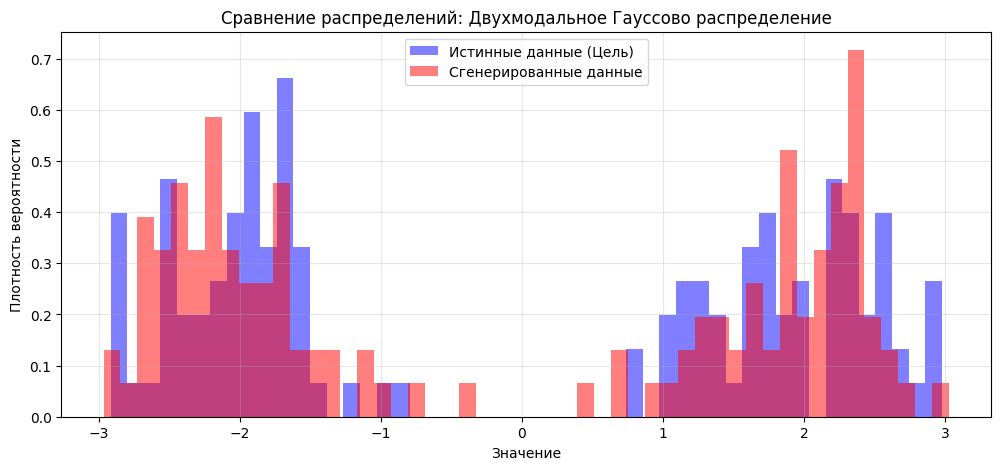

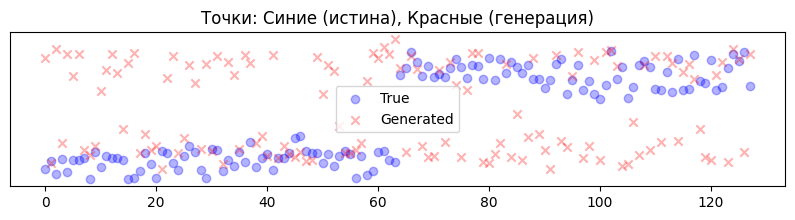

In [ ]:

plt.figure(figsize=(12, 5))


true_data = get_data_batch().cpu().numpy()
plt.hist(true_data, bins=50, alpha=0.5, label='Истинные данные', color='blue', density=True)


generated_data = x_sample.cpu().numpy()
plt.hist(generated_data, bins=50, alpha=0.5, label='Сгенерированные данные', color='red', density=True)

plt.title('Сравнение распределений: Двухмодальное Гауссово распределение')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 2))
plt.scatter(np.arange(len(true_data)), true_data, c='blue', alpha=0.3, label='True')
plt.scatter(np.arange(len(generated_data)), generated_data + 0.5, c='red', alpha=0.3, label='Generated', marker='x') # Сдвинул чуть вверх для видимости
plt.yticks([])
plt.legend()
plt.title('Точки: Синие (истина), Красные (генерация)')
plt.show()